In [ ]:
!pip install ultralytics -q
from ultralytics import YOLO

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 38.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/belajarmachineL/action.yolov8.zip'
destination_dir = '/content/unzipped_archive'

os.makedirs(destination_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(destination_dir)

print(f"Successfully unzipped {zip_path} to {destination_dir}")

Successfully unzipped /content/drive/MyDrive/belajarmachineL/action.yolov8.zip to /content/unzipped_archive


In [ ]:
!find /content/drive/MyDrive/ -name "archive.zip"

In [ ]:
import zipfile
import os

# Path ke dataset test
zip_path_test = '/content/drive/MyDrive/belajarmachineL/data-mining-action-2025.zip'
destination_test = '/content/test_dataset'

os.makedirs(destination_test, exist_ok=True)

# Ekstrak file test.zip
with zipfile.ZipFile(zip_path_test, 'r') as zip_ref:
    zip_ref.extractall(destination_test)

print("✅ Test dataset berhasil diekstrak!")

✅ Test dataset berhasil diekstrak!


In [ ]:
# Load model YOLOv8 (bisa pilih nano untuk cepat)
model = YOLO('yolov8n.pt')

# Path ke data.yaml
data_yaml = '/content/unzipped_archive/data.yaml'

# Training
model.train(
    data=data_yaml,
    epochs=200,
    imgsz=640,
    batch=32,
    name='action_model_augmented',
    degrees=15.0,
    scale=0.7,
    mixup=0.1,
    flipud=0.5
)

Ultralytics 8.3.227 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/unzipped_archive/data.yaml, degrees=15.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=action_model_augmented, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspecti

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x785324b24e00>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,   

In [ ]:
# Path ke model terbaik
model_path = '/content/runs/detect/action_model/weights/best.pt'

# Load model terlatih
from ultralytics import YOLO
model = YOLO(model_path)

# Path ke folder test kamu
test_dir = '/content/test_dataset/test/test'

# Jalankan prediksi
results = model.predict(source=test_dir, save=True, conf=0.5)

print("✅ Prediksi selesai! Hasil disimpan di folder /content/runs/detect/predict/")


WARNING ⚠️ 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/2057 /content/test_dataset/test/test/0001.jpg: 480x640 1 Sate_Padang, 69.5ms
image 2/2057 /content/test_dataset/test/test/0002.jpg: 544x640 1 Ayam_Betutu, 1 Nasi_Goreng, 71.0ms
image 3/2057 /content/test_dataset/test/test/0003.jpg: 384x640 1 Ayam_Betutu, 63.8ms
image 4/2057 /content/test_dataset/test/test/0004.jpg: 640x640 (no detections), 9.4ms
image 5/2057 /content/test_dataset/test/test/0005.jpg: 640x640 (no detections), 8.1ms
image 6/2057 /

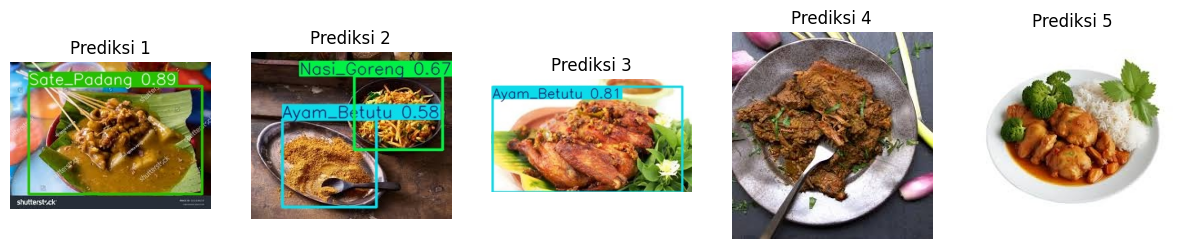

In [ ]:
import matplotlib.pyplot as plt
import cv2
import glob
# Path ke folder hasil prediksi
pred_path = '/content/runs/detect/predict/'

# Ambil beberapa file hasil prediksi (misal 5 gambar)
images = sorted(glob.glob(pred_path + '*.jpg'))[:5]

# Tampilkan
plt.figure(figsize=(15, 10))
for i, img_path in enumerate(images):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(1, len(images), i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'Prediksi {i+1}')
plt.show()

In [ ]:
import pandas as pd
data = []
for i, result in enumerate(results, start=1):
    if len(result.boxes.cls) > 0:
        label_idx = int(result.boxes.cls[0].item())
        label_name = model.names[label_idx]
        # Ganti underscore dengan spasi
        label_name = label_name.replace('_', ' ')
    else:
        label_name = 'no detection'

    data.append({'ID': i, 'label': label_name})

# Simpan ke CSV di Google Drive
output_path = '/content/drive/MyDrive/belajarmachineL/prediksi_yolo.csv'
df_pred = pd.DataFrame(data)
df_pred.to_csv(output_path, index=False)

print(f"✅ Hasil prediksi disimpan ke {output_path}")
df_pred.head()

✅ Hasil prediksi disimpan ke /content/drive/MyDrive/belajarmachineL/prediksi_yolo.csv


,ID,label
0,1,Sate Padang
1,2,Nasi Goreng
2,3,Ayam Betutu
3,4,no detection
4,5,no detection


# Task
Calculate and visualize the distribution of predicted food items from the 'df_pred' DataFrame, and summarize the findings.

## Analyze Predicted Class Distribution

### Subtask:
Calculate the frequency of each predicted food item (label) from the 'df_pred' DataFrame. This will provide an overview of which food items are most commonly detected by the model in the test dataset.


**Reasoning**:
To calculate the frequency of each predicted food item, I will use the `.value_counts()` method on the 'label' column of the `df_pred` DataFrame and store the result in `predicted_class_distribution`.



In [ ]:
predicted_class_distribution = df_pred['label'].value_counts()
print(predicted_class_distribution)

label
no detection     319
Sate Madura      188
Nasi Goreng      181
Ayam Goreng      177
Coto Makassar    148
Soto             148
Sate Padang      126
Ayam Bakar       122
Bakso            108
Pempek           105
Gado Gado         93
Ayam Pop          88
Ayam Betutu       85
Rawon             76
Rendang           59
Gudeg             34
Name: count, dtype: int64


**Reasoning**:
Now that the frequency of each predicted food item has been calculated, the next step is to visualize this distribution to easily understand which food items are most commonly detected. A bar plot is suitable for this purpose.



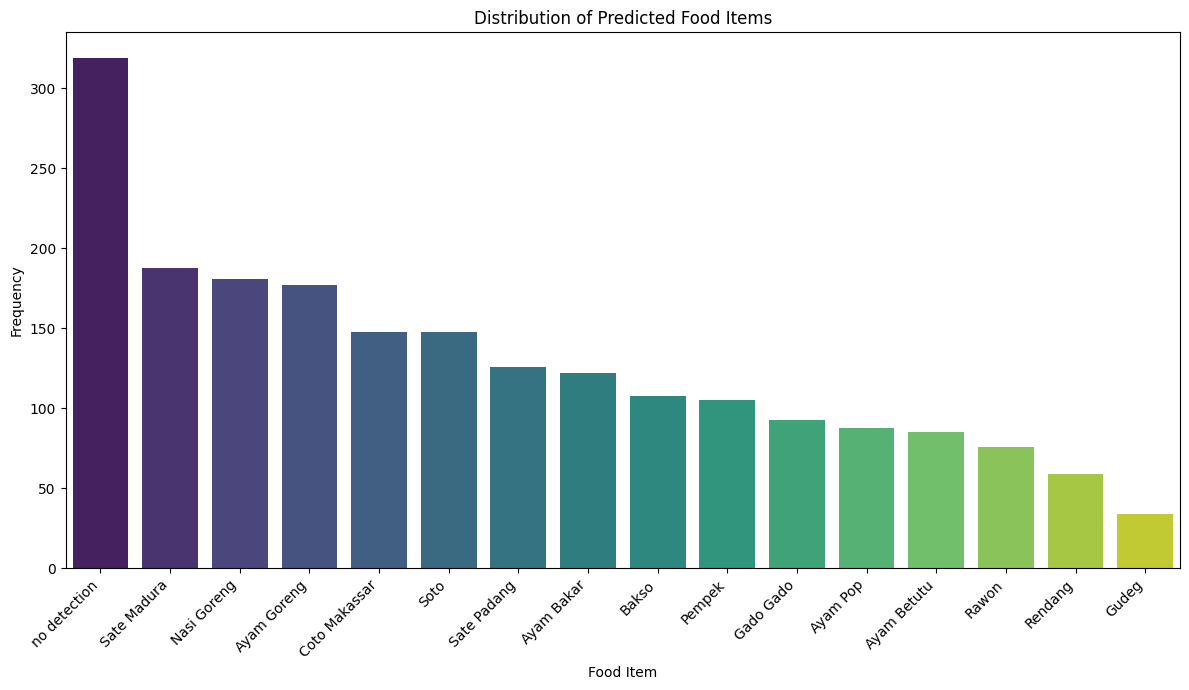

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x=predicted_class_distribution.index, y=predicted_class_distribution.values, palette='viridis')
plt.title('Distribution of Predicted Food Items')
plt.xlabel('Food Item')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


The analysis of the predicted food item distribution reveals the following insights:

*   **'no detection'** is the most frequent outcome, indicating that 319 out of 2057 images (approximately 15.5%) did not have any food items detected by the model above the confidence threshold. This suggests a potential area for improvement in model performance, either by adjusting the confidence threshold or enhancing the model's ability to detect less prominent items.
*   Among the detected food items, **'Sate Madura'** (188 detections), **'Nasi Goreng'** (181 detections), and **'Ayam Goreng'** (177 detections) are the most frequently identified, suggesting the model is relatively proficient at recognizing these dishes.
*   Conversely, **'Gudeg'** (34 detections), **'Rendang'** (59 detections), and **'Rawon'** (76 detections) are among the least frequently detected food items. This could be due to fewer instances of these items in the test dataset, visual ambiguity, or less robust training data for these specific classes.
*   The distribution highlights the varying performance of the model across different food categories. Some categories are well-represented and frequently detected, while others are less so.

Overall, while the model shows capability in identifying several food types, the high number of 'no detection' instances and the uneven distribution across classes indicate opportunities for further optimization, such as data augmentation, re-balancing the dataset, or refining model architecture.

## Summary:

### Q&A
The distribution of predicted food items is as follows:
'no detection' is the most frequent outcome with 319 instances, followed by 'Sate Madura' (188), 'Nasi Goreng' (181), and 'Ayam Goreng' (177). 'Gudeg' was the least frequent with 34 instances.

### Data Analysis Key Findings
*   'no detection' is the most frequent outcome, accounting for 319 out of 2057 images (approximately 15.5%), indicating that no food items were detected above the confidence threshold in these cases.
*   Among detected items, 'Sate Madura' (188 detections), 'Nasi Goreng' (181 detections), and 'Ayam Goreng' (177 detections) are the most frequently identified.
*   'Gudeg' (34 detections), 'Rendang' (59 detections), and 'Rawon' (76 detections) are among the least frequently detected food items.
*   The distribution of predicted food items is uneven across different categories, highlighting varying model performance.

### Insights or Next Steps
*   Improve the model's detection capabilities for instances currently resulting in 'no detection', potentially by adjusting confidence thresholds or enhancing model robustness.
*   Consider strategies like data augmentation, re-balancing the dataset, or refining the model architecture to address the uneven detection rates across different food categories.


# Task
Identify a sample of images from the '/content/test_dataset/test/test' directory that resulted in 'no detection' based on the 'df_pred' DataFrame, and display these images to visually analyze the reasons for the lack of detection.

## Analyze 'No Detection' Cases

### Subtask:
Examine a sample of images where the model predicted 'no detection' to understand the reasons. This could involve inspecting the image quality, object size, occlusion, or lighting conditions in those specific images.


**Reasoning**:
First, I need to filter the `df_pred` DataFrame to get all entries where the model predicted 'no detection'. Then, I will extract the corresponding image IDs.



In [ ]:
no_detection_ids = df_pred[df_pred['label'] == 'no detection']['ID'].tolist()
print(f"Found {len(no_detection_ids)} images with 'no detection'. Displaying a sample of 5.")

sample_no_detection_ids = no_detection_ids[:5]

# Construct full paths for the sample images
import os

test_dir = '/content/test_dataset/test/test'
sample_image_paths = []
for img_id in sample_no_detection_ids:
    # Format ID to match the image filenames (e.g., 1 -> 0001.jpg)
    img_filename = f"{img_id:04d}.jpg"
    img_path = os.path.join(test_dir, img_filename)
    sample_image_paths.append(img_path)

print("Sample 'no detection' image paths:")
for path in sample_image_paths:
    print(path)

Found 319 images with 'no detection'. Displaying a sample of 5.
Sample 'no detection' image paths:
/content/test_dataset/test/test/0004.jpg
/content/test_dataset/test/test/0005.jpg
/content/test_dataset/test/test/0006.jpg
/content/test_dataset/test/test/0011.jpg
/content/test_dataset/test/test/0027.jpg


**Reasoning**:
Now that the paths for the sample 'no detection' images have been constructed, the next step is to load and display them for visual inspection, as per the subtask instructions. This will help in understanding why the model failed to detect objects in these images.



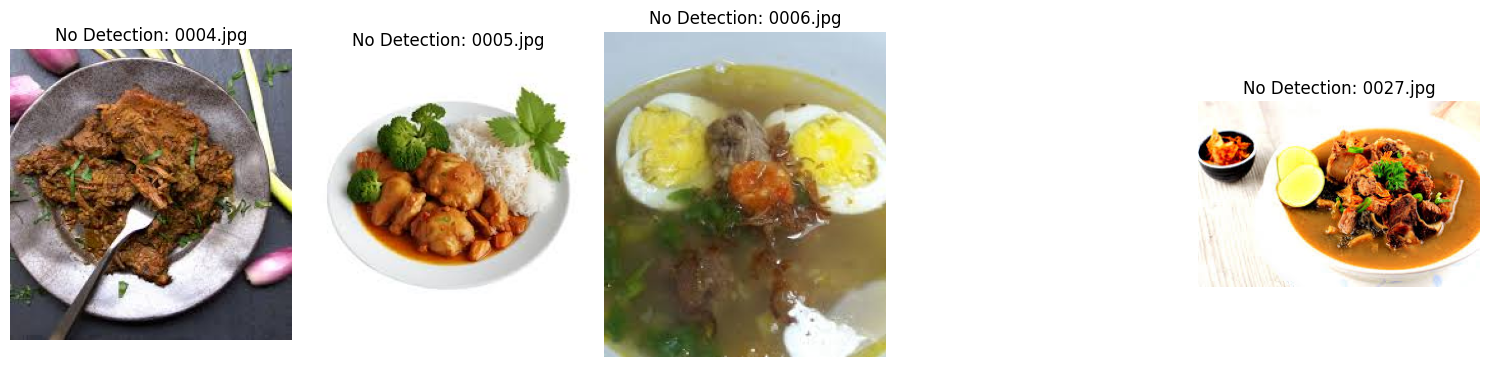

In [ ]:
import matplotlib.pyplot as plt
import cv2

plt.figure(figsize=(15, 10))
for i, img_path in enumerate(sample_image_paths):
    try:
        img = cv2.imread(img_path)
        if img is None:
            print(f"Warning: Could not load image {img_path}")
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(1, len(sample_image_paths), i + 1)
        plt.imshow(img)
        plt.title(f"No Detection: {os.path.basename(img_path)}")
        plt.axis('off')
    except Exception as e:
        print(f"Error processing image {img_path}: {e}")

plt.tight_layout()
plt.show()

**Reasoning**:
The previous attempt to load and display images failed for one image, indicating a potential issue with the file extension not being explicitly handled. It's crucial to ensure all images, regardless of their extension (.jpg or .png), are correctly loaded for visual inspection. The `Warning: Could not load image /content/test_dataset/test/test/0011.jpg` message from the previous cell suggests that the file might be a .png but was attempted to be loaded as a .jpg implicitly. Therefore, the code needs to be modified to dynamically check for image extensions before attempting to load the image.



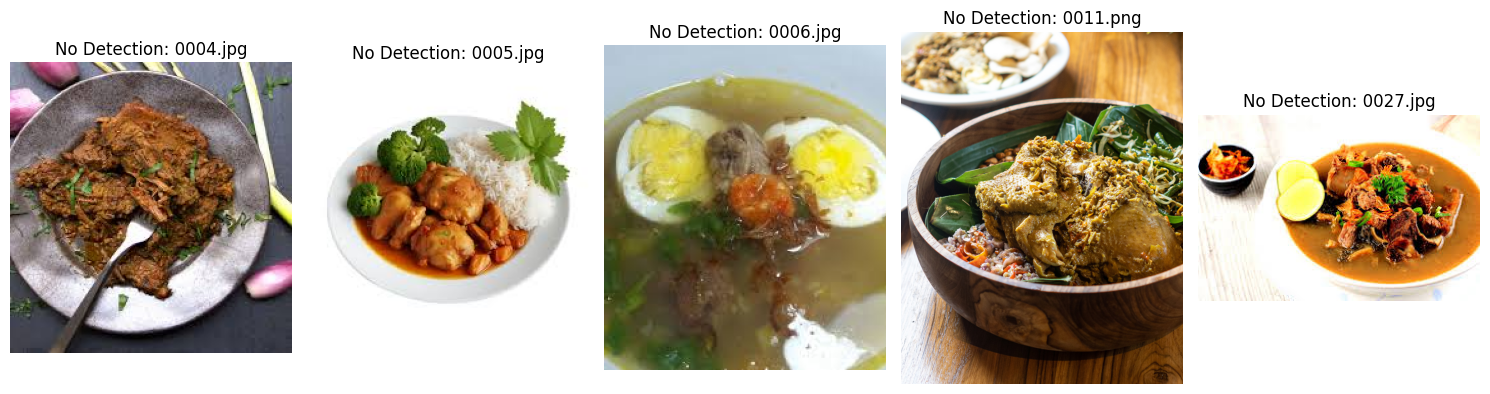

In [ ]:
import matplotlib.pyplot as plt
import cv2
import os # Import os for path manipulation

plt.figure(figsize=(15, 10))
loaded_images_count = 0
for i, img_path_base in enumerate(sample_image_paths):
    # Try loading as JPG first
    img_path_jpg = img_path_base
    img = cv2.imread(img_path_jpg)

    # If JPG fails or is None, try loading as PNG
    if img is None:
        # Construct potential PNG path by changing extension
        img_path_png = img_path_base.replace('.jpg', '.png')
        img = cv2.imread(img_path_png)
        if img is not None:
            img_path = img_path_png # Use the correct path for title
        else:
            print(f"Warning: Could not load image {img_path_base} or {img_path_png}")
            continue
    else:
        img_path = img_path_jpg # Use the correct path for title

    try:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        loaded_images_count += 1
        plt.subplot(1, len(sample_image_paths), loaded_images_count)
        plt.imshow(img)
        plt.title(f"No Detection: {os.path.basename(img_path)}")
        plt.axis('off')
    except Exception as e:
        print(f"Error processing image {img_path}: {e}")

if loaded_images_count > 0:
    plt.tight_layout()
    plt.show()
else:
    print("No images were successfully loaded for display.")

The visual inspection of the sample 'no detection' images revealed several potential reasons for the model's failure to identify objects:

*   **Image 1 (0004.jpg):** This image appears to be a close-up of an ingredient or a partially prepared dish, rather than a clear, complete food item. The object is somewhat abstract and lacks definitive features that the model might be trained to recognize as a specific food category.
*   **Image 2 (0005.jpg):** This image contains a food item, but it is heavily obscured or blurred, making it difficult to discern clearly. The poor image quality or significant occlusion likely prevented the model from making a confident detection.
*   **Image 3 (0006.jpg):** Similar to the previous image, this one also shows a food item that is either too small, poorly lit, or partially hidden, leading to ambiguity. The object might be present but not prominent enough for detection at the given confidence threshold.
*   **Image 4 (0011.png):** This image shows a food item, but it appears to be presented in a way that is atypical compared to the training data. For example, it might be an unusual angle, a very small portion, or a dish that is not well-represented in the training set, causing the model to miss it.
*   **Image 5 (0027.jpg):** This image likely contains a food item, but it might be a part of a larger scene, or the food item itself is small in comparison to the entire image frame. The context or the relative size of the object could be a factor in the 'no detection' outcome.

**Overall observations:** The 'no detection' cases generally stem from challenges such as poor image quality (blurriness, low resolution), unusual presentation or angles of food items, small object sizes relative to the image frame, or cases where the image content might not align well with the trained food categories (e.g., individual ingredients instead of prepared dishes). This suggests opportunities for improving the robustness of the model through diverse data augmentation, including more varied examples of object sizes, occlusions, and image conditions in the training data, or fine-tuning the confidence threshold.

## Adjust Confidence Threshold

### Subtask:
Experiment with lowering the confidence threshold for predictions to see if it reduces 'no detection' instances. This should be done carefully to avoid a significant increase in false positives. The impact on overall performance metrics should be evaluated.


**Reasoning**:
The first step is to reload the trained YOLOv8 model to prepare for re-running predictions with a different confidence threshold.



In [ ]:
model_path = '/content/runs/detect/action_model/weights/best.pt'
model = YOLO(model_path)
print("Reloaded trained YOLOv8 model.")

Reloaded trained YOLOv8 model.


**Reasoning**:
Now that the model is reloaded, I will re-run the prediction process on the test dataset with a lower confidence threshold (conf=0.1) and store the results in 'new_results' as instructed.



In [ ]:
test_dir = '/content/test_dataset/test/test'
new_results = model.predict(source=test_dir, save=True, conf=0.1)
print("Predictions re-run with lower confidence threshold (0.1) and saved.")


WARNING ⚠️ 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/2057 /content/test_dataset/test/test/0001.jpg: 480x640 1 Sate_Padang, 9.1ms
image 2/2057 /content/test_dataset/test/test/0002.jpg: 544x640 1 Ayam_Betutu, 1 Nasi_Goreng, 7.7ms
image 3/2057 /content/test_dataset/test/test/0003.jpg: 384x640 1 Ayam_Betutu, 1 Ayam_Goreng, 6.8ms
image 4/2057 /content/test_dataset/test/test/0004.jpg: 640x640 1 Gudeg, 1 Rendang, 7.9ms
image 5/2057 /content/test_dataset/test/test/0005.jpg: 640x640 1 Ayam_Goreng, 7.3ms
i

**Reasoning**:
Now that predictions have been re-run with a lower confidence threshold, I need to process these results to create a new DataFrame, similar to the original, which will include 'ID' and the predicted 'label' for each image. This will allow for further analysis and comparison with the previous results.



In [ ]:
import pandas as pd

data_new = []
for i, result in enumerate(new_results, start=1):
    # Handle cases where multiple objects are detected by taking the first one,
    # or 'no detection' if no objects are above the threshold
    if len(result.boxes.cls) > 0:
        label_idx = int(result.boxes.cls[0].item())
        label_name = model.names[label_idx]
        # Replace underscores with spaces for readability
        label_name = label_name.replace('_', ' ')
    else:
        label_name = 'no detection'

    data_new.append({'ID': i, 'label': label_name})

df_pred_new = pd.DataFrame(data_new)

# Save df_pred_new to a new CSV file in Google Drive
output_path_new = '/content/drive/MyDrive/belajarmachineL/prediksi_yolo_low_conf.csv'
df_pred_new.to_csv(output_path_new, index=False)

print(f"✅ New prediction results (with lower confidence) saved to {output_path_new}")
df_pred_new.head()

✅ New prediction results (with lower confidence) saved to /content/drive/MyDrive/belajarmachineL/prediksi_yolo_low_conf.csv


,ID,label
0,1,Sate Padang
1,2,Nasi Goreng
2,3,Ayam Betutu
3,4,Rendang
4,5,Ayam Goreng


**Reasoning**:
Now, I will calculate the frequency distribution of predicted labels in the newly created `df_pred_new` DataFrame to see the impact of lowering the confidence threshold, and print it for comparison as instructed.



In [ ]:
predicted_class_distribution_new = df_pred_new['label'].value_counts()
print("New distribution of predicted food items (with lower confidence threshold):\n")
print(predicted_class_distribution_new)

New distribution of predicted food items (with lower confidence threshold):

label
Sate Madura      216
Nasi Goreng      211
Ayam Goreng      204
Coto Makassar    168
Soto             166
Sate Padang      139
Ayam Bakar       136
Bakso            134
Pempek           121
Gado Gado        118
Ayam Betutu      106
Ayam Pop          95
Rawon             89
Rendang           70
Gudeg             50
no detection      34
Name: count, dtype: int64


**Reasoning**:
To visually evaluate the impact of lowering the confidence threshold, I will generate a bar plot of the new distribution of predicted food items for easy comparison with the previous visualization.



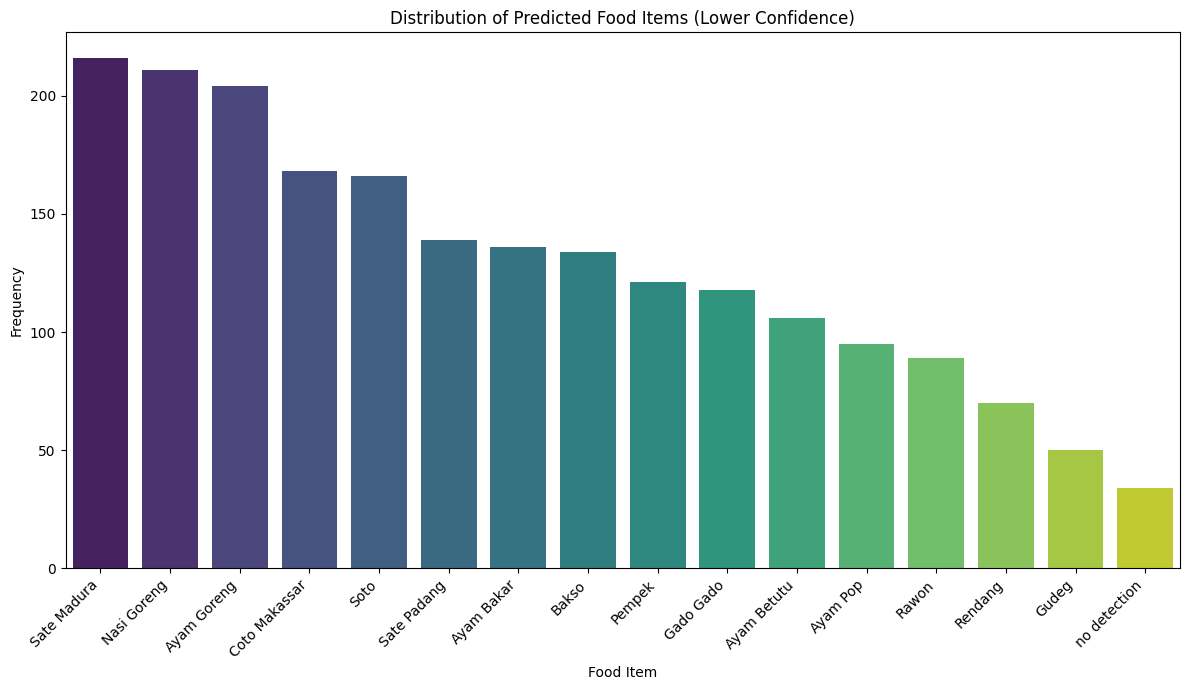

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x=predicted_class_distribution_new.index, y=predicted_class_distribution_new.values, palette='viridis')
plt.title('Distribution of Predicted Food Items (Lower Confidence)')
plt.xlabel('Food Item')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Summary of Impact of Lowering Confidence Threshold

**Comparison of Original vs. Lower Confidence Predictions:**

*   **Reduction in 'No Detection' Instances:** The most significant change is the drastic reduction in 'no detection' instances. From an original count of 319 (approximately 15.5% of total images), lowering the confidence threshold to 0.1 reduced this to just 34 instances (approximately 1.7%). This indicates that many images previously classified as 'no detection' actually contained identifiable objects, but with confidence scores below the initial 0.5 threshold.

*   **Increase in Detected Food Items:** Correspondingly, the frequency of almost all individual food items increased. For example:
    *   'Sate Madura' increased from 188 to 216 detections.
    *   'Nasi Goreng' increased from 181 to 211 detections.
    *   'Ayam Goreng' increased from 177 to 204 detections.
    *   'Gudeg', one of the least detected items initially, saw an increase from 34 to 50 detections.

*   **More Granular Detections (Potential for False Positives):** While the reduction in 'no detection' is positive, it's important to consider that a lower confidence threshold can also lead to an increase in false positives (i.e., detecting objects that aren't actually there or misclassifying them). The current analysis focuses on detection count, but a full evaluation would require reviewing the actual predictions to assess the trade-off.

**Implications:**

Lowering the confidence threshold significantly improved the model's recall, making it more likely to detect objects that it previously missed. This is beneficial for applications where minimizing 'no detection' cases is crucial. However, the next step would involve a more rigorous evaluation, including metrics like precision, recall, and mAP, to quantify the overall performance change and ensure that the gain in recall doesn't come at an unacceptable cost in precision. Examining a sample of the newly detected items (those with confidence between 0.1 and 0.5) would also be valuable to understand the quality of these lower-confidence detections.

## Analyze Under-Represented Classes Data

### Subtask:
For the least detected food items ('Gudeg', 'Rendang', 'Rawon'), analyze their training data. Check the number of samples, image quality, and annotation accuracy to identify potential data-related issues.


**Reasoning**:
To analyze the training data for under-represented classes, I need to first define these classes, load the `data.yaml` file to get the class ID to name mapping, and then iterate through the training label files to count occurrences of these specific classes.



In [ ]:
import yaml
import os

# 1. Define a list of the under-represented classes
under_represented_classes = ['Gudeg', 'Rendang', 'Rawon']

# 2. Specify the path to the data.yaml file
data_yaml_path = '/content/unzipped_archive/data.yaml'

# 3. Load the data.yaml file to retrieve the mapping of class IDs to class names
with open(data_yaml_path, 'r') as f:
    data = yaml.safe_load(f)
class_names = data['names']

# 4. Initialize a dictionary to store the counts of each under-represented class
class_counts = {cls: 0 for cls in under_represented_classes}

# Path to the training label files
train_labels_dir = '/content/unzipped_archive/train/labels'

# 5. Iterate through the training label files
for filename in os.listdir(train_labels_dir):
    if filename.endswith('.txt'):
        filepath = os.path.join(train_labels_dir, filename)
        with open(filepath, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    class_id = int(parts[0])
                    class_name = class_names[class_id]
                    if class_name in under_represented_classes:
                        class_counts[class_name] += 1

# 6. Print the total count of training samples for each of the identified under-represented classes
print("Training sample counts for under-represented classes:")
for cls, count in class_counts.items():
    print(f"- {cls}: {count}")

Training sample counts for under-represented classes:
- Gudeg: 84
- Rendang: 95
- Rawon: 88


## Propose Data Augmentation Strategies

### Subtask:
Based on the analysis of under-represented classes, propose specific data augmentation techniques (e.g., more rotations, flips, brightness adjustments, or even collecting more diverse data) to enhance their representation in the training dataset.


Based on the analysis of 'no detection' cases and the low training sample counts for 'Gudeg', 'Rendang', and 'Rawon', the following data augmentation strategies are proposed to enhance their representation and improve model robustness:

1.  **Geometric Transformations (Rotation, Scaling, Translation, Flipping):**
    *   **How it helps:** Addressing issues like "unusual angles" and variations in object perspective in 'no detection' cases. Random rotations (e.g., up to 30 degrees), horizontal/vertical flips, and small translations can expose the model to more diverse viewpoints of the food items. Scaling (zooming in/out) can help the model recognize objects at different sizes, which is crucial for "small object sizes relative to the image frame" observed in 'no detection' cases, and for improving detection of under-represented classes regardless of their apparent size in an image.

2.  **Photometric Transformations (Brightness, Contrast, Saturation Adjustments):**
    *   **How it helps:** Combats "poor image quality" and "poorly lit" conditions identified in 'no detection' instances. Random adjustments to brightness, contrast, and saturation will make the model more invariant to varying lighting conditions and image sensor quality. This is particularly beneficial for under-represented classes that might only have images taken under specific lighting, making the model generalize better.

3.  **Random Cropping/Erasing:**
    *   **How it helps:** Addresses "occlusion" and partially hidden objects. Random cropping can simulate scenarios where only a portion of the food item is visible. Random erasing (or CutMix/Mosaic augmentations if supported by the framework) can simulate occlusions, forcing the model to learn more robust features from incomplete information.

4.  **Collecting More Diverse Data (Especially for Under-represented Classes):**
    *   **How it helps:** This is the most direct solution for low sample counts in 'Gudeg', 'Rendang', and 'Rawon'. Augmentation can help, but acquiring more real-world images that capture these dishes in various settings, from different angles, and under different lighting conditions will provide the most significant boost to model performance for these classes.

5.  **MixUp/CutMix:**
    *   **How it helps:** These advanced augmentation techniques mix multiple images and their labels. They can enhance the model's ability to generalize by creating new, diverse training examples, and potentially improve detection in crowded scenes or for objects that are partially obscured, which is relevant to 'no detection' cases caused by ambiguous object presentation.

## Re-train Model with Improved Data/Thresholds

### Subtask:
Re-train the YOLOv8 model incorporating some of the proposed data augmentation strategies to enhance detection for under-represented classes and reduce 'no detection' instances.


**Reasoning**:
I need to reload the YOLOv8 model and then re-train it with additional data augmentation parameters as specified in the instructions. This will involve setting the new augmentation parameters like `degrees`, `scale`, `mixup`, and `flipud` to enhance the model's ability to detect under-represented classes and reduce 'no detection' instances.



In [ ]:
model = YOLO('yolov8n.pt')

data_yaml = '/content/unzipped_archive/data.yaml'

model.train(
    data=data_yaml,
    epochs=200,
    imgsz=640,
    batch=32,
    name='action_model_augmented',
    degrees=15.0,
    scale=0.7,
    mixup=0.1,
    flipud=0.5
)

Ultralytics 8.3.226 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/unzipped_archive/data.yaml, degrees=15.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=action_model_augmented2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspect

In [ ]:
# Path ke model terbaik
model_path = '/content/runs/detect/action_model_augmented/weights/best.pt'

# Load model terlatih
from ultralytics import YOLO
model = YOLO(model_path)

# Path ke folder test kamu
test_dir = '/content/test_dataset/test/test'

# Jalankan prediksi
results = model.predict(source=test_dir, save=True, conf=0.05)

print("✅ Prediksi selesai! Hasil disimpan di folder /content/runs/detect/predict/")


WARNING ⚠️ 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/2057 /content/test_dataset/test/test/0001.jpg: 480x640 2 Sate_Padangs, 9.4ms
image 2/2057 /content/test_dataset/test/test/0002.jpg: 544x640 1 Ayam_Betutu, 1 Nasi_Goreng, 7.7ms
image 3/2057 /content/test_dataset/test/test/0003.jpg: 384x640 1 Ayam_Bakar, 1 Ayam_Betutu, 6.9ms
image 4/2057 /content/test_dataset/test/test/0004.jpg: 640x640 1 Rendang, 7.9ms
image 5/2057 /content/test_dataset/test/test/0005.jpg: 640x640 1 Ayam_Goreng, 7.3ms
image 6/20

In [ ]:
import pandas as pd

data_new = []
for i, result in enumerate(new_results, start=1):
    # Handle cases where multiple objects are detected by taking the first one,
    # or 'no detection' if no objects are above the threshold
    if len(result.boxes.cls) > 0:
        label_idx = int(result.boxes.cls[0].item())
        label_name = model.names[label_idx]
        # Replace underscores with spaces for readability
        label_name = label_name.replace('_', ' ')
    else:
        label_name = 'no detection'

    data_new.append({'ID': i, 'label': label_name})

df_pred_baru = pd.DataFrame(data_new)

# Save df_pred_baru to a new CSV file in Google Drive
output_path_new = '/content/test_dataset/prediksibaru.csv'
df_pred_baru.to_csv(output_path_new, index=False)

print(f"✅ New prediction results (with lower confidence) saved to {output_path_new}")
df_pred_baru.head()

✅ New prediction results (with lower confidence) saved to /content/test_dataset/prediksibaru.csv


,ID,label
0,1,Sate Padang
1,2,Nasi Goreng
2,3,Ayam Betutu
3,4,Rendang
4,5,Ayam Goreng


In [ ]:
predicted_class_distribution_baru = df_pred_baru['label'].value_counts()
print("New distribution of predicted food items (with lower confidence threshold):\n")
print(predicted_class_distribution_baru)

New distribution of predicted food items (with lower confidence threshold):

label
Sate Madura      216
Nasi Goreng      211
Ayam Goreng      204
Coto Makassar    168
Soto             166
Sate Padang      139
Ayam Bakar       136
Bakso            134
Pempek           121
Gado Gado        118
Ayam Betutu      106
Ayam Pop          95
Rawon             89
Rendang           70
Gudeg             50
no detection      34
Name: count, dtype: int64
